# Домашнее задание 2: DPO и PPO

В этой домашке поближе познакомимся с двумя крайне популярными методами алаймента языковых моделей. В первой части вам предоставится возможность самостоятельно заимплементить DPO c нуля. Во второй части мы уже будем использовать библиотеку TRL и обучим PPO.

Обученные модели можно и нужно выложить на [🤗 HuggingFace](https://huggingface.co/). Зарегистрируйтесь там, подпишитесь на [deep vk](https://huggingface.co/deepvk) и создайте себе API токен.

Следуйте ячейкам тетрадки и заполняйте пропущенные ячейки. В конце тетрадки вы найдете задачи со звездочкой, чтобы получить максимальный балл!

## Импорты и вспомогательные функции

In [2]:
# Установим необходимые дополнительные библиотеки

%pip install --quiet datasets trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.7/335.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Необходимые импорты (для обоих частей)
import inspect
import random
from functools import partial

import numpy as np
import torch
import torch.nn.functional as F
import wandb
from datasets import load_dataset
from huggingface_hub import HfApi, interpreter_login
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    PreTrainedTokenizerBase,
)
from trl import PPOConfig, PPOTrainer, RewardConfig, RewardTrainer

In [4]:
interpreter_login()


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Add token as git credential? (Y/n) Y


In [5]:
# Подготовим репозиторий для будущей модели и токенизатора
username = HfApi().whoami()["name"]
REPO_NAME = f"{username}/llm-course-hw2"  # Или как вам хочется

print(f"Homework repository: '{REPO_NAME}'")

Homework repository: 'Aleks2002SH/llm-course-hw2'


In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


# Этой функцией будут помечены все места, которые необходимо дозаполнить
# Это могут быть как целые функции, так и отдельные части внутри них
# Всегда можно воспользоваться интроспекцией и найти места использования этой функции :)
def todo():
    stack = inspect.stack()
    caller_frame = stack[1]
    function_name = caller_frame.function
    line_number = caller_frame.lineno
    raise NotImplementedError(f"TODO at {function_name}, line {line_number}")


def disable_dropout_in_model(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = 0

# Часть 1: DPO

Крайне простой метод, который в свое время произвел фурор, т.к. выгодно выделялся на фоне PPO. В отличие от PPO, требующего отдельно обучать Reward Model, Value Model и больших усилий в имплементации, DPO не требует явной ревард модели, а только датасета с человеческими преференсами вида: промпт, выбранный человеком ответ, отвергнутный человеком ответ. Простота также видна из лосса, по сути это весь метод:
$$
L_\text{DPO}(\pi_{\theta}; \pi_\text{ref}) = -E_{(x, y_w, y_l)\sim D}\left[\log \sigma \left(
\beta \log \frac{\pi_{\theta}(y_w\mid x)}{\pi_\text{ref}(y_w\mid x)} \thinspace
{- \beta \log \frac{\pi_{\theta}(y_l\mid x)}{\pi_\text{ref}(y_l\mid x)}}\right)\right]
$$

где:

- $\pi_{\theta}$ LLM которую мы хотим заалайнить
- $\pi_\text{ref}$ референсная модель для регуляризации, как правило просто начальный чекпоинт
- $D$ датасет с преференсами
- $x$ промпт из датасета $D$
- $y_w$ ответ на промпт $x$ выбранный человеком (или тем кто размечал преференсы, это может быть и большая LLM)
- $y_l$ ответ на промпт $x$ отвергнутый человеком (или тем кто размечал преференсы, это может быть и большая LLM)
- $\beta$ гиперепараметр отвечающий за то, как далеко мы можем отходить от референсной модели

Во время имплементации советум внимательно прочитать оригинальную статью: [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290).

Для файнтюна мы будем использовать модель [HuggingFaceTB/SmolLM-135M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM-135M-Instruct), т.к. она маленького размера (поместится на Colab), но при этом умеет достаточно, чтобы увидеть изменения от алаймента. Более того, данная модель даже прошла стадию SFT, а поэтому в отличие от базовой модели (без Instruct) понимает формат чата (chat-template в transformers, дальше разберем) и имеет 'осознание' себя языковым ассистентом.

P.S. Если у вас есть доступ к вычислительным ресурсам типо A100 и больше, вы можете попробовать зафайнтюнить модель большего размера из этой же [линейки](https://huggingface.co/blog/smollm). Будьте внимательны, смотрите, чтобы она была с добавкой Instruct.

In [6]:
MODEL_ID = "HuggingFaceTB/SmolLM-135M-Instruct"
DATASET_ID = "HumanLLMs/Human-Like-DPO-Dataset"

## Подготовка данных [2 балла]

Для начала нужно подготовить данные. В качестве датасета преференсов мы будем использовать [HumanLLMs/Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset), который значительно повышает эмоциональность модели, количество используемых эмодзи и в целом снижает строгость следования шаблону "As a conversational AI, I ...".

Чтобы подготовить датасет нужно несколько простых этапов:
1. Привест данные к формату chat-template
2. После применить этот chat-template с помощью 'tokenizer.apply_chat_template'
3. Токенизировать получившиеся данные, попутно обрезав промпт и ответы до нужной длины, если надо.

Внимательно прочитайте [документацию по chat-templates](https://huggingface.co/docs/transformers/chat_templating). Для удобства данные приводят в начале в более верхне-уровневый формат такого вида:
```python
messages = [
    {"role": "system", "content": "You are a helpful assistant focused on technical topics."},
    {"role": "user", "content": "Can you explain what a chat template is?"},
    {"role": "assistant", "content": "A chat template structures conversations between users and AI models..."}
]
```
То есть модели можно задать разные роли, такие как например системный промпт, и в целом структурировать диалог между ассистентом и человеком. Обычно обучение этому происходит на этапе SFT. Данная репрезентация абстрагирует детали (конкретные токены) как этот формат используют разные модели. Чтобы перевести его в неспоредственно текстовый инпут в формате специфичном конкретной модели используется `tokenizer.apply_chat_template`.

In [ ]:
# понадобится для подготовки данных
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/3.59k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

In [ ]:
dataset = load_dataset(DATASET_ID, split="train")
dataset[0]

README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

data.json:   0%|          | 0.00/28.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10884 [00:00<?, ? examples/s]

{'prompt': 'Oh, I just saw the best meme - have you seen it?',
 'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣",
 'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?"}

Приведите датасет к формату чата, где у промпта роль user, а у ответов assistant, а потом примените чат темплейт:

In [ ]:
def apply_chat_template(example: dict[str, str], tokenizer: PreTrainedTokenizerBase) -> dict[str, str]:
    """
    Transforms a dataset example into a formatted chat template using the provided tokenizer.

    Args:
        example (Dict[str, str]): A dictionary containing the following keys:
            - "prompt": The initial user prompt.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.
        tokenizer (PreTrainedTokenizerBase): An object that provides the `apply_chat_template` method
            for formatting the conversation.

    Returns:
        Dict[str, str]: A dictionary with the following keys:
            - "prompt": The formatted prompt string including the generation prompt.
            - "chosen": The formatted assistant's chosen response (with the prompt prefix removed).
            - "rejected": The formatted assistant's rejected response (with the prompt prefix removed).
    """
    output_dict = dict()
    output_dict['prompt'] = "<|im_start|>user\n"+example['prompt']+"<|im_end|>\n<|im_start|>assistant\n"
    output_dict['chosen'] = example['chosen']
    output_dict['rejected'] =example['rejected']
    return output_dict


In [ ]:
dataset = dataset.map(apply_chat_template, fn_kwargs={"tokenizer": tokenizer})
dataset[0]

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

{'prompt': '<|im_start|>user\nOh, I just saw the best meme - have you seen it?<|im_end|>\n<|im_start|>assistant\n',
 'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣",
 'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?"}

После этих двух этапов данные должны выглядеть так (**обратите внимание на положение <|im_start|>assistant\n**, это важно!):
```
{
    'prompt': "<|im_start|>user\nOh, I just saw the best meme - have you seen it <|im_end|>\n<|im_start|>assistant\n",
    'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>\n",
    'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?<|im_end|>\n"
}
```

Токенизируйте датасет с помощью токенизатора, обрезав длину если необходимо. В датасете должны остаться только ID токенов:
```
Dataset({
    features: ['prompt_input_ids', 'chosen_input_ids', 'rejected_input_ids'],
    num_rows: 10884
})
```

Обрезайте промпт слева, а не с конца. Подумайте почему так лучше. **Напишите свой ответ**.

    #========== TODO ==========
    #     Ваш ответ здесь     =
    #==========================

In [ ]:
def tokenize_row(
    example: dict[str, str],
    tokenizer: PreTrainedTokenizerBase,
    max_prompt_length: int = 512,
    max_completion_length: int | None = None,
) -> dict[str, list[int]]:
    """
    Tokenizes a single row of a dataset example for use in language model training or evaluation.

    This function processes an example containing textual fields for a prompt, a chosen response,
    and a rejected response. It tokenizes each text field using the provided tokenizer. If specified,
    it truncates the tokenized prompt to the last `max_prompt_length` tokens and the tokenized responses
    (chosen and rejected) to the first `max_completion_length` tokens.

    Args:
        example (dict[str, str]): A dictionary with the following keys:
            - "prompt": The initial prompt text.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.
        tokenizer (PreTrainedTokenizerBase): A tokenizer that converts text into token IDs. It must return a dictionary
            with the key "input_ids" when called.
        max_prompt_length (Optional[int], optional): Maximum number of tokens to retain for the prompt.
            The function keeps the last `max_prompt_length` tokens. Defaults to 512.
        max_completion_length (Optional[int], optional): Maximum number of tokens to retain for the completion
            responses (chosen and rejected). The function keeps the first `max_completion_length` tokens.
            If None, no truncation is applied. Defaults to None.

    Returns:
        dict[str, list[int]]: A dictionary containing:
            - "prompt_input_ids": The token IDs for the prompt, possibly truncated.
            - "chosen_input_ids": The token IDs for the chosen response, possibly truncated.
            - "rejected_input_ids": The token IDs for the rejected response, possibly truncated.
    """
    output_dict = dict()
    output_dict['prompt_input_ids'] = tokenizer(example['prompt'])['input_ids'][-max_prompt_length:]
    output_dict['chosen_input_ids'] = tokenizer(example['chosen'])['input_ids']
    output_dict['rejected_input_ids'] = tokenizer(example['rejected'])['input_ids']
    if max_completion_length is not None:
        output_dict['chosen_input_ids'] = output_dict['chosen_input_ids'][:max_completion_length]
        output_dict['rejected_input_ids'] = output_dict['rejected_input_ids'][:max_completion_length]
    return output_dict

In [ ]:
dataset = dataset.map(
    tokenize_row,
    fn_kwargs={
        "tokenizer": tokenizer,
        "max_prompt_length": 256,
        "max_completion_length": None,
    },
    remove_columns=["prompt", "chosen", "rejected"],
)

dataset[0]

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

{'prompt_input_ids': [1,
  4093,
  198,
  16912,
  28,
  339,
  915,
  3680,
  260,
  1450,
  1169,
  85,
  731,
  457,
  346,
  2269,
  357,
  47,
  2,
  198,
  1,
  520,
  9531,
  198],
 'chosen_input_ids': [10813,
  242,
  220,
  12947,
  28,
  787,
  339,
  8540,
  982,
  17,
  339,
  5248,
  11888,
  288,
  699,
  28,
  732,
  506,
  260,
  1169,
  85,
  563,
  47,
  1431,
  357,
  253,
  17025,
  2644,
  355,
  253,
  31404,
  3223,
  47,
  1691,
  388,
  260,
  9973,
  17,
  15107,
  114,
  113],
 'rejected_input_ids': [57,
  5248,
  354,
  6416,
  5290,
  1789,
  1743,
  28,
  339,
  1326,
  982,
  457,
  2143,
  2647,
  355,
  8428,
  30,
  1423,
  28,
  339,
  416,
  1538,
  346,
  351,
  1096,
  335,
  3452,
  29,
  3119,
  284,
  9603,
  32246,
  9411,
  28,
  347,
  876,
  347,
  7400,
  1552,
  335,
  1678,
  14009,
  355,
  5535,
  30,
  13651,
  346,
  702,
  549,
  288,
  1820,
  634,
  7703,
  10026,
  355,
  1692,
  253,
  1542,
  10265,
  282,
  1384,
  47]}

Теперь надо подготовить DataLoader. Для этого надо написать кастомный `collate_fn` который будет делать следующее:
1. Принимать лист примеров с ключами `prompt_input_ids`, `chosen_input_ids`, `rejected_input_ids`.
2. Паддить до максимальной длины в батче по каждому ключу. По итогу `prompt_input_ids` и `chosen_input_ids` могут иметь разную длину, это нормально. Важно, чтобы внутри одинаковых ключей длина была консистентна.
3. Для каждого ключа создавать паддинг маску такого же шейпа, где 0 используется для паддинг-токенов и 1 для токенов последовательности.

Для паддинга дополнительно реализуйте функцию `pad`. В качестве токена используйте `tokenizer.pad_token_id` и 0 для маски. **Опять же, подумайте откуда лучше паддить `prompt_input_ids`?**

Лучше паддить данные слева, потому что модель должна генерировать ответ, начиная с реальных токенов. LLM не генерируют данные с паддинг-токенов.



In [ ]:
def pad(tensors: list[torch.Tensor], padding_value: int = 0, padding_side: str = "right") -> torch.Tensor:
    """
    Pads a list of tensors to the same size along their leading dimension.

    Args:
        tensors (list[torch.Tensor]): A list of tensors to be padded.
            All tensors in the list should be of the same type and device.
        padding_value (int, default=0): The value used to pad the tensors.
        padding_side (str, default="right"): Specifies which side of the tensor to apply padding: either 'left' or 'right'.

    Returns:
        torch.Tensor: A tensor containing all the padded tensors, [N; max_length]
            where N is the number of tensors and `max_length` is the shape of the largest tensor.
    """
    max_pad_length = max(tensor.shape[0] for tensor in tensors)
    padded_tensors = []
    attention_masks = []
    for tensor in tensors:
        pad_length = max_pad_length - tensor.shape[0]
        attention_mask = torch.zeros((max_pad_length))
        if padding_side == "right":
            padded_tensor = F.pad(tensor, (0, pad_length), value=padding_value)
            attention_mask[:tensor.shape[0]] = 1
        elif padding_side =='left':
            padded_tensor = F.pad(tensor, (pad_length, 0), value=padding_value)
            attention_mask[tensor.shape[0]:] = 1
        else:
            raise ValueError(f"Unsupported padding side: {padding_side}, must be a string either right or left")
        padded_tensors.append(padded_tensor)
        attention_masks.append(attention_mask)
    return torch.stack(padded_tensors),torch.stack(attention_masks)


def pad_collate_fn(batch: list[dict[str, torch.Tensor]], pad_token_id: int) -> dict[str, torch.Tensor]:
    """
    Collates and pads a batch of tokenized examples for model input.

    This function takes a batch of examples where each example is a dictionary containing
    token IDs for the prompt, the chosen response, and the rejected response. For each field,
    it extracts the list of token IDs, creates a corresponding attention mask (with ones for each token),
    and then pads the sequences using a `pad` function. The prompt sequences and their attention masks
    are padded on the left, while the chosen and rejected sequences are padded on the right (default).

    Args:
        batch (list[dict[str, torch.Tensor]]): A list of dictionaries, where each dictionary has the keys:
            - "prompt_input_ids": Tensor of token IDs for the prompt.
            - "chosen_input_ids": Tensor of token IDs for the chosen response.
            - "rejected_input_ids": Tensor of token IDs for the rejected response.
        pad_token_id (int): Padding value for token IDs.

    Returns:
        dict[str, torch.Tensor]: A dictionary containing the following keys with padded tensors:
            - "prompt_input_ids": Padded token IDs for the prompt (padded on the left).
            - "prompt_attn_mask": Padded attention mask for the prompt (padded on the left, with 1s for actual tokens).
            - "chosen_input_ids": Padded token IDs for the chosen response.
            - "chosen_attn_mask": Padded attention mask for the chosen response.
            - "rejected_input_ids": Padded token IDs for the rejected response.
            - "rejected_attn_mask": Padded attention mask for the rejected response.
    """
    output_dict = dict()
    prompt_inputs = []
    chosen_inputs = []
    rejected_inputs = []
    for b in range(len(batch)):
        prompt_inputs.append(batch[b]['prompt_input_ids'])
        chosen_inputs.append(batch[b]['chosen_input_ids'])
        rejected_inputs.append(batch[b]['rejected_input_ids'])
    output_dict['prompt_input_ids'], output_dict['prompt_attn_mask'] = pad(prompt_inputs, pad_token_id, padding_side='left')
    output_dict['chosen_input_ids'], output_dict['chosen_attn_mask'] = pad(chosen_inputs, pad_token_id, padding_side='right')
    output_dict['rejected_input_ids'], output_dict['rejected_attn_mask'] = pad(rejected_inputs, pad_token_id, padding_side='right')
    return output_dict


In [ ]:
dataloader = DataLoader(
    dataset.with_format("torch"),
    batch_size=2,
    shuffle=True,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)

In [ ]:
next(iter(dataloader))

{'prompt_input_ids': tensor([[    2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
              2,     1,  4093,   198,  1937,   346,   856,   325,   354,  4507,
            281,  3534,    28,   732,   736,   357,   325,    47,     2,   198,
              1,   520,  9531,   198],
         [    1,  4093,   198,  1937,   346,   856,  6143,   750, 14840,  2121,
            365,    85,    30,    87,    30,   253,  4732,   281,   253,  7704,
            355,  1863,   643,   732,   736,   357,   325,    47,     2,   198,
              1,   520,  9531,   198]]),
 'prompt_attn_mask': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 'chosen_input_ids': tensor([[ 5195,   506,   253,  1109,  1962,    17, 15107,   114

## DPO Loss [5 баллов]

Начнем с имплементации самой функции потерь. Она достаточно простая, следуйте формуле дословно и все получится.

In [ ]:
def dpo_loss(
    chosen_logps: torch.Tensor,
    rejected_logps: torch.Tensor,
    ref_chosen_logps: torch.Tensor,
    ref_rejected_logps: torch.Tensor,
    beta: float = 0.1,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes the Direct Preference Optimization (DPO) loss and associated reward metrics.

    Args:
        chosen_logps (Tensor): A tensor of shape (batch_size,) containing the log-probabilities of the chosen responses.
        rejected_logps (Tensor): A tensor of shape (batch_size,) containing the log-probabilities of the rejected responses.
        ref_chosen_logps (Tensor): A tensor of shape (batch_size,) containing the reference log-probabilities for chosen responses.
        ref_rejected_logps (Tensor): A tensor of shape (batch_size,) containing the reference log-probabilities for rejected responses.
        beta (float, optional): A scaling factor applied to the differences in log-probabilities. Defaults to 0.1.

    Returns:
        tuple[Tensor, Tensor, Tensor]:
            - loss (Tensor): The computed DPO loss as a scalar tensor.
            - reward_accuracies (Tensor): The fraction of examples where the chosen reward exceeds the rejected reward.
            - reward_margins (Tensor): The average difference between the chosen and rejected rewards.
    """
    reward_diff = (chosen_logps-ref_chosen_logps)-(rejected_logps-ref_rejected_logps)
    L_dpo = -F.logsigmoid(beta*(reward_diff)).mean()
    reward_accuracies = (reward_diff>0).float().mean()
    reward_margins = reward_diff.mean()
    return L_dpo, reward_accuracies, reward_margins


Для удобста также определим отдельную функцию чтобы считать лог-пробы по логитам. Вам нужно вытащить логиты реальных токенов из последовательности. Не забудьте замаскировать лог-пробы промпта перед аггрегацией. Маска здесь уже дана.

Подсказка: внимательно подумайте как соотносятся логпробы и настоящие индексы, иначе рискуете ошибиться на 1

In [ ]:
def get_log_prob(logits: torch.Tensor, labels: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    Computes the log probability for each sequence in a batch.

    Args:
        logits (Tensor): A tensor of shape [batch_size, seq_len, vocab_size]
            representing the model's output logits.
        labels (Tensor): A tensor of shape [batch_size, seq_len] containing the target token indices.
        mask (Tensor): A tensor of shape [batch_size, seq_len] indicating which tokens to include
            in the log probability (e.g., 1 for valid tokens and 0 for padding or prompt).

    Returns:
        Tensor: A tensor of shape [batch_size,] containing the log probability for each sequence.
    """
    log_probs = torch.log_softmax(logits,dim=-1)
    log_probs = log_probs.gather(dim=-1,index = labels.unsqueeze(-1)).squeeze(-1)
    log_probs = log_probs*mask
    log_probs = log_probs.sum(dim=-1)
    return log_probs

## Обучение DPO [5 баллов]

На всякий случай инициализируем модель, токенизатор и датасет с нуля.
Для простоты ограничимся обычным циклом, без конфигов, классов и прочего.
Вы можете переписать как удобно вам, главное сохранить корректность.

Все нужное у нас уже есть, осталось собрать это все вместе.
Для этого нужно получить логпробы для промпт+выбранный и промпт+отвергнутый ответы.
Не забыть правильно собрать маску для лосса.
В конце обрезать финальные входы для модели до `MAX_SEQ_LEN` (с нужной стороны!).

Обучение занимает примерно час на Colab T4 GPU, 2 минут на H100. В Colab лучше использовать float16 и AMP.
Не забудьте про скейлинг. Для bf16 он не обязателен.

**NB**: для обучения лучше использовать Kaggle Notebooks, т.к. они не вылетают если долго не взаимодействовать с тетрадкой. Их можно оставлять на час без боязни, что они упадут.

In [ ]:
BATCH_SIZE = 2 # in colab make it smaller, or implement grad accumulation
NUM_EPOCHS = 1
LR = 5e-5
MAX_SEQ_LEN = 128  # this also can be adjusted
MAX_PROMPT_LEN = 32 # this also can be adjusted
MAX_COMPLETION_LEN = None
BETA = 1.0

# опционально, если вам хочется логгировать метрики в W&B
ENABLE_WANDB = False

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using '{DEVICE}' device")

Using 'cuda' device


In [ ]:
set_seed(42)

if ENABLE_WANDB:
    wandb.init(project="hw2-rlhf", group="dpo")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
model.train()
disable_dropout_in_model(model)

ref_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
ref_model.eval()
disable_dropout_in_model(ref_model)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.map(apply_chat_template, fn_kwargs={"tokenizer": tokenizer})
dataset = dataset.map(
    tokenize_row,
    fn_kwargs={
        "tokenizer": tokenizer,
        "max_prompt_length": MAX_PROMPT_LEN,
        "max_completion_length": MAX_COMPLETION_LEN,
    },
    remove_columns=["prompt", "chosen", "rejected"],
)
dataloader = DataLoader(
    dataset.with_format("torch"),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    losses, accs, margins = [], [], []

    pbar = tqdm(dataloader, desc="Epoch", leave=False)
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        # ========== TODO ==========
        #      Ваш код здесь       =
        # ==========================

        # 1. Concatenate the prompt and completion inputs for chosen & rejected
        chosen_inputs = torch.cat([batch['prompt_input_ids'],batch['chosen_input_ids']],dim=1)
        rejected_inputs = torch.cat([batch['prompt_input_ids'],batch['rejected_input_ids']],dim=1)

        # 2. Calculate logits for current and reference models for chosen and rejected samples
        chosen_logits = model(chosen_inputs).logits
        rejected_logits = model(rejected_inputs).logits

        with torch.no_grad():
          ref_chosen_logits = ref_model(chosen_inputs).logits
          ref_rejected_logits = ref_model(rejected_inputs).logits

        # 3. Calculate log probs for all models (no concat as in TRL for simplicity and to save memory with smaller batch size)
        chosen_masks = torch.cat([batch['prompt_attn_mask'],batch['chosen_attn_mask']],dim=1)
        rejected_masks = torch.cat([batch['prompt_attn_mask'],batch['rejected_attn_mask']],dim=1)
        chosen_log_probs = get_log_prob(chosen_logits[:,:-1],chosen_inputs[:,1:],chosen_masks[:,:-1])
        rejected_log_probs = get_log_prob(rejected_logits[:,:-1],rejected_inputs[:,1:],rejected_masks[:,:-1])
        ref_chosen_log_probs = get_log_prob(ref_chosen_logits[:,:-1],chosen_inputs[:,1:],chosen_masks[:,:-1])
        ref_rejected_log_probs = get_log_prob(ref_rejected_logits[:,:-1],rejected_inputs[:,1:],rejected_masks[:,:-1])


        # 4. Calculate loss
        loss,reward_accuracies,reward_margins = dpo_loss(chosen_log_probs,rejected_log_probs,ref_chosen_log_probs,ref_rejected_log_probs)

        chosen_logits = chosen_logits.cpu()
        rejected_logits = rejected_logits.cpu()
        ref_chosen_logits = ref_chosen_logits.cpu()
        ref_rejected_logits = ref_rejected_logits.cpu()
        chosen_log_probs = chosen_log_probs.cpu()
        rejected_log_probs = rejected_log_probs.cpu()
        ref_chosen_log_probs = ref_chosen_log_probs.cpu()
        ref_rejected_log_probs = ref_rejected_log_probs.cpu()


        del chosen_logits, rejected_logits, ref_chosen_logits, ref_rejected_logits,chosen_log_probs,rejected_log_probs,ref_chosen_log_probs,ref_rejected_log_probs
        torch.cuda.empty_cache()

        # 5. Make optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accs.append(reward_accuracies.item())
        margins.append(reward_margins.item())
        pbar.set_postfix({"Reward margins": np.mean(margins), "Reward acc": np.mean(accs)})

        if ENABLE_WANDB:
            wandb.log(
                {
                    "loss": loss.item(),
                    "train-reward-margins": reward_margins.item(),
                    "train-reward-accuracy": reward_accuracies.item(),
                    "epoch": epoch,
                }
            )

    pbar.close()

Epoch:   0%|          | 0/5442 [00:00<?, ?it/s]

Во время обучения reward margins и accuracy должны были расти. Давайте проверим что изменилось после обучения:

In [ ]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

generated_ids = model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=True)
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

init_generated_ids = ref_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=True)
init_response = tokenizer.batch_decode(init_generated_ids, skip_special_tokens=True)[0]

print("======== BEFORE TUNING ========")
print(init_response)
print()

print("======== AFTER TUNING ========")
print(response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


======== BEFORE TUNING ========
user
What's your morning routine like?
assistant
Morning routines can be a daunting task, but here's a sample daily routine that you might find helpful:

**Set Reminders (30 minutes)**

1. Wake up: Use the alarm clock.
2. Stretch or move around: Do some light exercises like yoga or jumping jacks to get your blood flowing.
3. Meditate: Close your eyes, focus on your breath, and relax your shoulders.

**Eat Breakfast (5-10 minutes)**

1. Start with the basics: oatmeal, scrambled eggs, or toast on a whole-grain bun.
2. Fill up on breakfast items: yogurt, fruit, and a cup of coffee or tea with milk.
3. Keep important notes in your phone: a note on the fridge with notes about your commute, tasks that need to be accomplished, or important dates you might miss.

**Take a Walk or Do Some Exercise (15-30 minutes)**

1. Put on some music or nature sounds to help you get moving.
2. Break a sweat and grab a drink of water or a refreshing snack.
3. Exercise or do som

In [ ]:
# Загружаем все на хаб

model.push_to_hub(f"{REPO_NAME}-dpo", private=True)
tokenizer.push_to_hub(f"{REPO_NAME}-dpo", private=True)

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Aleks2002SH/llm-course-hw2-dpo/commit/d0e3d5d3387e610d2836fd839fd34c53ee78a919', commit_message='Upload tokenizer', commit_description='', oid='d0e3d5d3387e610d2836fd839fd34c53ee78a919', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aleks2002SH/llm-course-hw2-dpo', endpoint='https://huggingface.co', repo_type='model', repo_id='Aleks2002SH/llm-course-hw2-dpo'), pr_revision=None, pr_num=None)

# Часть 2: PPO и TRL

Вторая часть будет сильно проще и направлена на то, чтобы познакомиться с самой популярной библотекой для алаймента от huggingface - [TRL](https://huggingface.co/docs/trl/v0.15.0/index). C помощью TRL нужно будет обучить PPO, а для этого вначале обучить Reward Model.

**Лирическое отступление**: PPO имеет парадоксальную репутацию. С одной строны в RL он считается чуть ли не единственным применимым (до сих пор) на практике алгоритмом, который заводится с пол-пинка и на любой задаче. Основной боттлнек для него - данные, чем быстрее симулятор, там больше вероятность, что он вашу задачу решит. Примеров много - так решили Dota 2 или Minecraft. С другой стороны, у алгоритма крайне дурная репутация в плане имплементации с нуля, т.к. есть много важных и маленьких деталей, которые при неправильном исполнении приведут к незаметному, но крайне странному поведению. Дебагать это очень сложно, [чего стоит только этот список](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/) и [такой же для уже RLHF](https://huggingface.co/blog/the_n_implementation_details_of_rlhf_with_ppo), причем часто трюки не пересекаются между доменами. Более того, как раз из-за этого если вы загуглите имплементации PPO с нуля, с большой вероятностью большая часть будет с ошибками.

Поэтому кодить PPO без тесного знакомства и опыта в RL крайне не рекомендуется. Для RLHF лучше использовать TRL или аналоги, для RL лучше использовать [Sample-Factory](https://github.com/alex-petrenko/sample-factory).

## Обучение Reward Model [2 балл]

В отличие от DPO, который выводит апдейт явно, убирая необходимость в награде, для PPO награда нужна, а значит кто-то должен ее выдавать. В общем случае это может быть какая-то простая функция, например равенство с правильным ответом. Для PPO, TRL поддерживает только награды от других моделек (но это поправят в будущем).

Возьмем тот же датасет и попробуем обучить сами. Для обучения нам понадобится preference dataset with implicit prompt ([см. примеры в документации](https://huggingface.co/docs/trl/main/dataset_formats)). То есть должны быть только две колонки: chosen, rejected, каждая содержаящая в себе промпт. По аналогии, это все надо привести в темплейт чата.

Пример:
```python
## Implicit prompt
preference_example = {
    "chosen": [
        {"role": "user", "content": "What color is the sky?"},
        {"role": "assistant", "content": "It is blue."}
    ],
    "rejected": [
        {"role": "user", "content": "What color is the sky?"},
        {"role": "assistant", "content": "It is green."}
    ]
}
```

Подробнее про лосс который оптимизируется [тут](https://rlhfbook.com/c/07-reward-models.html). TRL все сделает за вас.

In [ ]:
def to_implicit_prompt_preferences(example: dict[str, str]) -> dict[str, list[dict[str, str]]]:
    """
    Converts an example into implicit prompt preferences format.

    Args:
        example (dict[str, str]): A dictionary with the following keys:
            - "prompt": The user's input prompt.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.

    Returns:
        dict[str, list[dict[str, str]]]: A dictionary containing:
            - "chosen": A list of messages forming the conversation for the chosen response.
            - "rejected": A list of messages forming the conversation for the rejected response.
    """
    output_dict = dict()
    output_dict['chosen'] = [{'role':'user','content':example['prompt']},{'role':'assistant','content':example['chosen']}]
    output_dict['rejected'] = [{'role':'user','content':example['prompt']},{'role':'assistant','content':example['rejected']}]
    return output_dict

In [ ]:
dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.map(to_implicit_prompt_preferences, remove_columns=["prompt"])
dataset = dataset.train_test_split(train_size=0.9)

README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

data.json:   0%|          | 0.00/28.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10884 [00:00<?, ? examples/s]

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

Использовать будем ту же модель, обучать только линейный слой поверх. Для модели используйте `AutoModelForSequenceClassification`. Обучите ревард модель с помощь `RewardConfig` и `RewardTrainer`. Одной эпохи должно быть достаточно (даже меньше). Для удобства подгрузите получившуюся модель на хаб.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# Важно, чтобы тренер правильно отработал для этой модели.
tokenizer.pad_token = tokenizer.eos_token

reward_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=1,
    attn_implementation="sdpa",
    torch_dtype=torch.bfloat16,
    device_map=DEVICE
    )

for param in reward_model.base_model.parameters():
    param.requires_grad = False

for param in reward_model.score.parameters():
    param.requires_grad = True

reward_model.train()
disable_dropout_in_model(reward_model)

reward_model.config.pad_token_id = tokenizer.pad_token_id

reward_config = RewardConfig(
    num_train_epochs=1,
    per_device_train_batch_size=16,
    max_length=1024,
    disable_dropout=True,
    learning_rate=3e-4,
    seed=42,
    logging_steps=25,
    output_dir = '/outputs',
    report_to="wandb" if ENABLE_WANDB else "none",
)
reward_trainer = RewardTrainer(
    model=reward_model,
    processing_class=tokenizer,
    args=reward_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

reward_trainer.train()

tokenizer_config.json:   0%|          | 0.00/3.59k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

...

Filter:   0%|          | 0/1089 [00:00<?, ? examples/s]

You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss
25,0.523000
50,0.355500
75,0.248000
100,0.170300


Step,Training Loss
25,0.523000
50,0.355500
75,0.248000
100,0.170300
125,0.145900
150,0.101800
175,0.098300
200,0.105200
225,0.083600
250,0.086800


TrainOutput(global_step=612, training_loss=0.1226403728809232, metrics={'train_runtime': 1553.7423, 'train_samples_per_second': 6.301, 'train_steps_per_second': 0.394, 'total_flos': 0.0, 'train_loss': 0.1226403728809232, 'epoch': 1.0})

Награда для chosen должна быть выше чем для rejected.

In [ ]:
inputs_chosen = tokenizer.apply_chat_template(dataset["test"][0]["chosen"], tokenize=False)
inputs_chosen = tokenizer(inputs_chosen, return_tensors="pt").to(DEVICE)

inputs_rejected = tokenizer.apply_chat_template(dataset["test"][0]["rejected"], tokenize=False)
inputs_rejected = tokenizer(inputs_rejected, return_tensors="pt").to(DEVICE)

score_chosen = reward_model(**inputs_chosen).logits[0].cpu().detach()
score_rejected = reward_model(**inputs_rejected).logits[0].cpu().detach()

In [ ]:
score_chosen, score_rejected

(tensor([-0.2461], dtype=torch.bfloat16),
 tensor([-3.1875], dtype=torch.bfloat16))

In [ ]:
# Загрузим reward модель на хаб

reward_trainer.push_to_hub(f"{REPO_NAME}-reward-model", dataset_name=DATASET_ID)

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

training_args.bin:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Aleks2002SH/outputs/commit/3c92b492b902fc9bf0a8e83ca8a15c0bab0385f2', commit_message='Aleks2002SH/llm-course-hw2-reward-model', commit_description='', oid='3c92b492b902fc9bf0a8e83ca8a15c0bab0385f2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aleks2002SH/outputs', endpoint='https://huggingface.co', repo_type='model', repo_id='Aleks2002SH/outputs'), pr_revision=None, pr_num=None)

## Обучение PPO [4 балла]

**WARN**: TRL недавно смержили большой рефактор PPO, забыв обновить всю документацию и примеры 🥴🥴🥴. Для правильных примеров смотрите в код, а не в докментацию. Если вам интересно знать виновных в лицо:

<a href="https://ibb.co/zTFL4GTt"><img src="https://i.ibb.co/1tMpm8t4/Screenshot-2025-02-13-at-17-40-48.png" alt="" border="0" /></a>

Для PPO нам понадобится тот же датасет, но уже в формате только prompt. Приведите prompt в чат темплейт и токенизируйте (`tokenizer.apply_chat_template`). Все остальные колонки можно удалить.

В качестве `policy`, `ref_policy` подгрузите SmolLM2-135M-Instruct, в качестве `reward_model`, `value_model` свою обученную ревард модель. Для обучения используйте `PPOConfig` и `PPOTrainer`.

In [ ]:
set_seed(42)
REWARD_MODEL_REPO_NAME = f"{REPO_NAME}-reward-model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")
tokenizer.add_special_tokens({"pad_token": "[PAD]"})

value_model = AutoModelForSequenceClassification.from_pretrained(
    REWARD_MODEL_REPO_NAME
    ).to(DEVICE)

reward_model = AutoModelForSequenceClassification.from_pretrained(
   REWARD_MODEL_REPO_NAME
    ).to(DEVICE)

reward_model.eval()
value_model.eval()

policy = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
policy.train()
disable_dropout_in_model(policy)



ref_policy = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
ref_policy.eval()
disable_dropout_in_model(ref_policy)

def tokenize(example, tokenizer):
    input_ids = tokenizer.apply_chat_template([{'role':'user','content':example['prompt']}], tokenize=True)
    return {'input_ids':input_ids}


dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.remove_columns(["chosen", "rejected"])
dataset = dataset.map(tokenize, fn_kwargs={"tokenizer": tokenizer}, remove_columns=dataset.column_names)
dataset = dataset.train_test_split()

training_args = PPOConfig(
    learning_rate=5e-5,
    num_train_epochs=1,
    num_ppo_epochs=2,
    mini_batch_size=4,
    batch_size=8,
    gradient_accumulation_steps=4,
    output_dir = '/outputs',
    report_to="wandb" if ENABLE_WANDB else "none",

)


trainer = PPOTrainer(
    args=training_args,
    model=policy,
    ref_model=ref_policy,
    reward_model=reward_model,
    value_model=value_model,
    processing_class = tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)
trainer.train()

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

===training policy===


Step,Training Loss


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ -0.11039960384368896 │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI     │                      │
│ getaway?                                    │ assistant, I don't have personal           │                      │
│                                             │ preferences, but I can provide you with    │                      │
│                                             │ some popular types of vacations and        │                      │
│                                             │ getaways that are often enjoyed by many    │                      │
│                                             │ people. Keep in mind that what one person  │                      │
│                                             │ enjoys,                                    │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 1.6392714977264404   │
│ Can you tell me about a memorable birthday  │ What a great question! As a conversational │                      │
│ or celebration you've had?                  │ AI, I don't have personal experiences, but │                      │
│                                             │ I can provide you with some insights and   │                      │
│                                             │ anecdotes about memorable birthday or      │                      │
│                                             │ celebration experiences.                   │                      │
│                                             │                                            │                      │
│                                             │ **Birthday Celebrations:**                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **The Great American                    │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.07812201976776123 │
│ Can you recommend a good book or podcast    │ I'd be happy to recommend some great books │                      │
│ you've consumed lately?                     │ and podcasts to help you improve your      │                      │
│                                             │ writing skills. Here are a few             │                      │
│                                             │ suggestions:                               │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.                          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_sta

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ 1.900888442993164    │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI     │                      │
│ getaway?                                    │ assistant, I don't have personal           │                      │
│                                             │ preferences, but I can provide you with    │                      │
│                                             │ some popular types of vacations and        │                      │
│                                             │ getaways that are often enjoyed by many    │                      │
│                                             │ people. Keep in mind that these are        │                      │
│                                             │ general trends and                         │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 3.0464019775390625   │
│ Can you tell me about a memorable birthday  │ What a great question! As a digital AI     │                      │
│ or celebration you've had?                  │ assistant, I don't have personal           │                      │
│                                             │ experiences or memories, but I can provide │                      │
│                                             │ you with some insights and anecdotes about │                      │
│                                             │ memorable birthday or celebration          │                      │
│                                             │ experiences.                               │                      │
│                                             │                                            │                      │
│                                             │ **The Power of Memories**                  │                      │
│                                             │                                            │                      │
│                                             │ Birth                                      │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.07812201976776123 │
│ Can you recommend a good book or podcast    │ I'd be happy to recommend some great books │                      │
│ you've consumed lately?                     │ and podcasts to help you improve your      │                      │
│                                             │ writing skills. Here are a few             │                      │
│                                             │ suggestions:                               │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.                          │                      │
├─────────────────────────────────────────────┼─────────

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                               ┃ score              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                        │ 0.6407883167266846 │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI       │                    │
│ getaway?                                    │ assistant, I don't have personal             │                    │
│                                             │ preferences, but I can provide you with some │                    │
│                                             │ popular and popular types of vacations and   │                    │
│                                             │ getaways that are often enjoyed by many      │                    │
│                                             │ people. Keep in mind that these are general  │                    │
├─────────────────────────────────────────────┼──────────────────────────────────────────────┼────────────────────┤
│ user                                        │ <|im_start|>assistant                        │ 3.2360706329345703 │
│ Can you tell me about a memorable birthday  │ What a great question! As a digital AI       │                    │
│ or celebration you've had?                  │ assistant, I don't have personal experiences │                    │
│                                             │ or memories, but I can share some memorable  │                    │
│                                             │ birthday or celebration experiences with     │                    │
│                                             │ you. Here are a few examples:                │                    │
│                                             │                                              │                    │
│                                             │ **Birthday:**                                │                    │
│                                             │                                              │                    │
│                                             │ * **                                         │                    │
├─────────────────────────────────────────────┼──────────────────────────────────────────────┼────────────────────┤
│ user                                        │ <|im_start|>assistant                        │ -0.406413733959198 │
│ Can you recommend a good book or podcast    │ What a great question! I'd be happy to       │                    │
│ you've consumed lately?                     │ recommend some great books and podcasts to   │                    │
│                                             │ help you improve your writing skills. Here   │                    │
│                                             │ are a few:                                   │                    │
│                                             │                                              │                    │
│                                             │ **Books:**                                   │                    │
│                                             │                                              │                    │
│                                             │ 1. **"The Elements of Style" by William      │                    │
│                                             │ Strunk Jr                                    │                    │
├─────────────────────────────────────────────┼──────────────────────────────────────────────┼────────────────────┤
│ user                                        │ <|im_start|>assistant                        │ 1.4637129306793213 │
│ Have you ever had a particularly memorable  │ What a g

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ 2.0454370975494385   │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI     │                      │
│ getaway?                                    │ assistant, I don't have personal           │                      │
│                                             │ preferences or desires, but I can provide  │                      │
│                                             │ you with some popular and popular types of │                      │
│                                             │ vacations and getaways that many people    │                      │
│                                             │ enjoy. Keep in mind that these are general │                      │
│                                             │ trends                                     │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 3.2360706329345703   │
│ Can you tell me about a memorable birthday  │ What a great question! As a digital AI     │                      │
│ or celebration you've had?                  │ assistant, I don't have personal           │                      │
│                                             │ experiences or memories, but I can share   │                      │
│                                             │ some memorable birthday or celebration     │                      │
│                                             │ experiences with you. Here are a few       │                      │
│                                             │ examples:                                  │                      │
│                                             │                                            │                      │
│                                             │ **Birthday:**                              │                      │
│                                             │                                            │                      │
│                                             │ * **                                       │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.07812201976776123 │
│ Can you recommend a good book or podcast    │ I'd be happy to recommend some great books │                      │
│ you've consumed lately?                     │ and podcasts to help you improve your      │                      │
│                                             │ writing skills. Here are a few             │                      │
│                                             │ suggestions:                               │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.                          │                      │
├─────────────────────────────────────────────┼─────────

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ 2.0454370975494385   │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI     │                      │
│ getaway?                                    │ assistant, I don't have personal           │                      │
│                                             │ preferences or desires, but I can provide  │                      │
│                                             │ you with some popular and popular types of │                      │
│                                             │ vacations and getaways that many people    │                      │
│                                             │ enjoy. Keep in mind that these are general │                      │
│                                             │ trends                                     │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 1.9984705448150635   │
│ Can you tell me about a memorable birthday  │ What a great question! As a digital AI     │                      │
│ or celebration you've had?                  │ assistant, I don't have personal           │                      │
│                                             │ experiences or memories, but I can provide │                      │
│                                             │ you with a hypothetical birthday           │                      │
│                                             │ celebration that I've come up with based   │                      │
│                                             │ on popular culture and trends. Please note │                      │
│                                             │ that this is just                          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.07812201976776123 │
│ Can you recommend a good book or podcast    │ I'd be happy to recommend some great books │                      │
│ you've consumed lately?                     │ and podcasts to help you improve your      │                      │
│                                             │ writing skills. Here are a few             │                      │
│                                             │ suggestions:                               │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.                          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 1.4637129306793213   │
│ Have you ever had a particularly memorable  │ What a great question! As a digital AI     │                      │
│ birthday? What made it so special?          │ assistan

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ 1.900888442993164    │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI     │                      │
│ getaway?                                    │ assistant, I don't have personal           │                      │
│                                             │ preferences, but I can provide you with    │                      │
│                                             │ some popular types of vacations and        │                      │
│                                             │ getaways that are often enjoyed by many    │                      │
│                                             │ people. Keep in mind that these are        │                      │
│                                             │ general trends and                         │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 0.9991907477378845   │
│ Can you tell me about a memorable birthday  │ What a great question! As a digital AI     │                      │
│ or celebration you've had?                  │ assistant, I don't have personal           │                      │
│                                             │ experiences or memories, but I can provide │                      │
│                                             │ you with a hypothetical birthday           │                      │
│                                             │ celebration that I've come up with based   │                      │
│                                             │ on popular culture and trends. Please note │                      │
│                                             │ that birthdays are often                   │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.07812201976776123 │
│ Can you recommend a good book or podcast    │ I'd be happy to recommend some great books │                      │
│ you've consumed lately?                     │ and podcasts to help you improve your      │                      │
│                                             │ writing skills. Here are a few             │                      │
│                                             │ suggestions:                               │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.                          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 1.4637129306793213   │
│ Have you ever had a particularly memorable  │ What a great question! As a digital AI     │                      │
│ birthday? What made it so special?          │ assistan

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ 1.900888442993164    │
│ Do you have a favorite type of vacation or  │ What a great question! As a digital AI     │                      │
│ getaway?                                    │ assistant, I don't have personal           │                      │
│                                             │ preferences, but I can provide you with    │                      │
│                                             │ some popular types of vacations and        │                      │
│                                             │ getaways that are often enjoyed by many    │                      │
│                                             │ people. Keep in mind that these are        │                      │
│                                             │ general trends and                         │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 1.9984705448150635   │
│ Can you tell me about a memorable birthday  │ What a great question! As a digital AI     │                      │
│ or celebration you've had?                  │ assistant, I don't have personal           │                      │
│                                             │ experiences or memories, but I can provide │                      │
│                                             │ you with a hypothetical birthday           │                      │
│                                             │ celebration that I've come up with based   │                      │
│                                             │ on popular culture and trends. Please note │                      │
│                                             │ that this is just                          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.07812201976776123 │
│ Can you recommend a good book or podcast    │ I'd be happy to recommend some great books │                      │
│ you've consumed lately?                     │ and podcasts to help you improve your      │                      │
│                                             │ writing skills. Here are a few             │                      │
│                                             │ suggestions:                               │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.                          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 3.6130385398864746   │
│ Have you ever had a particularly memorable  │ What a great question! As a digital AI     │                      │
│ birthday? What made it so special?          │ assistan

Посмотрим на изменение в ответах. Вполне вероятно, что вы не увидите такого сильного изменения как после DPO. PPO требует гораздо больше ресурсов, правильных гиперпараметров и в целом не так стабилен.

In [ ]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

generated_ids = policy.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

init_generated_ids = ref_policy.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
init_response = tokenizer.batch_decode(init_generated_ids, skip_special_tokens=True)[0]

In [ ]:
print("======== BEFORE TUNING ========")
print(init_response)
print()

print("======== AFTER TUNING ========")
print(response)

======== BEFORE TUNING ========
user
What's your morning routine like?
assistant
I'm excited to start my morning routine! As a digital AI assistant, I don't have personal preferences or habits, but I can provide you with a general idea of what a morning routine might look like. Here's a sample routine that I've developed based on various studies and research:

**Morning Routine (10-15 minutes)**

1. **Hydrate**: Drink a full glass of water or a herbal tea to start the day.
2. **Brush teeth**: Brush your teeth for 2 minutes, then rinse with water.
3. **Get dressed**: Put on some comfortable clothes, including a light jacket or sweater.
4. **Get ready for work**: Start with some morning exercise, such as a 10-minute yoga or stretching routine.
5. **Plan your day**: Review your schedule, set goals, and prioritize tasks.

**Morning Routine (15-30 minutes)**

1. **Get ready for work**: Start with some morning exercise, such as a 10-minute yoga or stretching routine.
2. **Get ready for work*

In [ ]:
# Загружаем все на хаб

policy.push_to_hub(f"{REPO_NAME}-ppo")
tokenizer.push_to_hub(f"{REPO_NAME}-ppo")

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Aleks2002SH/llm-course-hw2-ppo/commit/ddf5d84013c403f3b499e1897797450c8f56c256', commit_message='Upload tokenizer', commit_description='', oid='ddf5d84013c403f3b499e1897797450c8f56c256', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aleks2002SH/llm-course-hw2-ppo', endpoint='https://huggingface.co', repo_type='model', repo_id='Aleks2002SH/llm-course-hw2-ppo'), pr_revision=None, pr_num=None)

## Анализ модели [2 балл]

Проанализируйте финальный модель (от DPO и PPO).
Постройте графики логпроб для данных из обучающей выборки и сторонних, которые модель не видела.
Подойдет любой не сильно большой датасет с hugging face.

Считает ли финальная модель что данные из обучающей выборки более вероятны?

Попробуйте проанализировать финальную модель (от DPO или PPO). Постройте графики логпроб для данных из обучающей выборки и каких нибудь еще, которые модель не видела. Считает ли финальная модель что данные из обучающей выборки более вероятны?

In [ ]:
DEVICE = torch.device("cuda")
DPO_REPO_NAME = f"{REPO_NAME}-dpo"
PPO_REPO_NAME = f"{REPO_NAME}-ppo"
dpo_model =  AutoModelForCausalLM.from_pretrained(DPO_REPO_NAME,device_map = DEVICE)
ppo_model =  AutoModelForCausalLM.from_pretrained(PPO_REPO_NAME,device_map = DEVICE)
dpo_model.eval()
ppo_model.eval()
tokenizer = AutoTokenizer.from_pretrained(DPO_REPO_NAME)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/3.62k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

In [ ]:
def get_log_probs_batch(texts, model, tokenizer, batch_size=8):
    model.eval()
    all_log_probs = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Processing batches"):
        batch_texts = texts[i:i+batch_size]
        prompts = []
        for prompt in batch_texts['prompt']:
            prompts.append(tokenizer.apply_chat_template([{'role':'user','content':prompt}], tokenize=False))
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"]).logits
            log_probs = get_log_prob(outputs,inputs['input_ids'],inputs['attention_mask'])
        all_log_probs.extend(log_probs.cpu().numpy())
    return all_log_probs


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_log_probs(train_log_probs,test_log_probs,title):
  plt.figure(figsize=(10, 5))
  plt.hist(train_log_probs, bins=20, alpha=0.6, label="Train Data", color="brown")
  plt.hist(test_log_probs, bins=20, alpha=0.6, label="Test Data", color="lightpink")
  plt.xlabel("Log Probability")
  plt.ylabel("Frequency")
  plt.xlim(-2000,0)
  plt.legend()
  plt.title(title)
  plt.show()


In [ ]:
dataset_train = load_dataset(DATASET_ID)

TEST_DATASET_ID = 'fka/awesome-chatgpt-prompts'
dataset_test = load_dataset(TEST_DATASET_ID)

README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

data.json:   0%|          | 0.00/28.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10884 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/339 [00:00<?, ?B/s]

prompts.csv:   0%|          | 0.00/104k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203 [00:00<?, ? examples/s]

In [ ]:
train_log_probs_dpo = get_log_probs_batch(dataset_train['train'],dpo_model,tokenizer)
test_log_probs_dpo = get_log_probs_batch(dataset_test['train'],dpo_model,tokenizer)

train_log_probs_ppo = get_log_probs_batch(dataset_train['train'],ppo_model,tokenizer)
test_log_probs_ppo = get_log_probs_batch(dataset_test['train'],ppo_model,tokenizer)

Processing batches:   0%|          | 0/1361 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/26 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1361 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/26 [00:00<?, ?it/s]

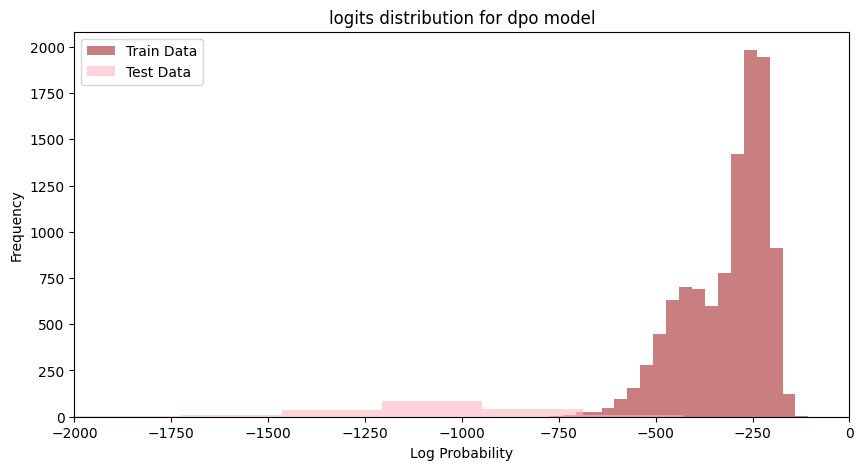

In [ ]:
plot_log_probs(train_log_probs_dpo,test_log_probs_dpo,'logits distribution for dpo model')


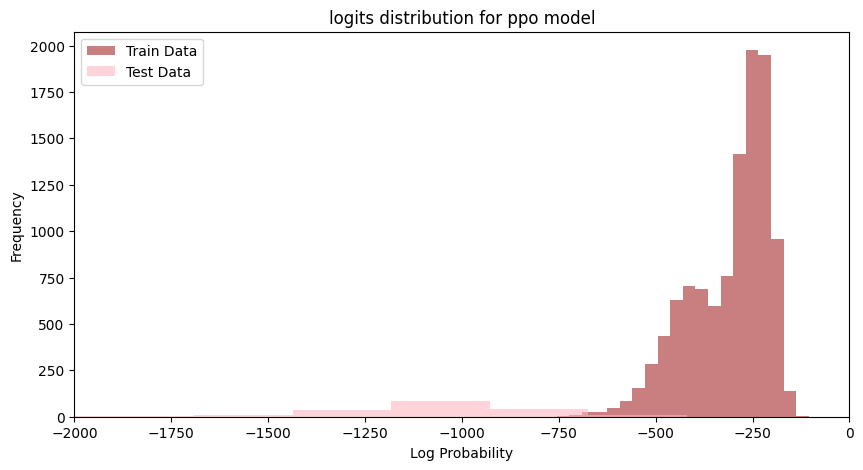

In [ ]:
plot_log_probs(train_log_probs_ppo,test_log_probs_ppo,'logits distribution for ppo model')

Распределения логитов у PPO и DPO моделей похожи. Видно, что обе модели считают данные из обучающей выборки более вероятными, чем из тестовой, о чем свидетельсвтуют низкие log probs для тестовой выборки. В качестве теста использовался датасет https://huggingface.co/datasets/fka/awesome-chatgpt-prompts/viewer , но в этом датасете запросы посложнее и имеют более техническую направленность. Вот пример одного из промпта:
I want you to act as a linux terminal. I will type commands and you will reply with what the terminal should show. I want you to only reply with the terminal output inside one unique code block, and nothing else. do not write explanations. do not type commands unless I instruct you to do so. when i need to tell you something in english, i will do so by putting text inside curly brackets {like this}. my first command is pwd

Поэтому такой результат вполне очевиден.

Коллекция с репозиториями: https://huggingface.co/collections/Aleks2002SH/llm-course-hw2-67e8354aa694ef0ab77c8073

# Дополнительные баллы

Вы также можно заработать дополнительные баллы:
- Оформить репозитории на 🤗 (можно сделать коллекцию, так как у нас 3 репозитория): карточка модели с описанием задания, репортом качества и примерами генерации **[2 балла]**

# Специальный раздел для проверяющего

In [7]:
device = torch.device("cuda")

DPO_REPO_NAME = f"{REPO_NAME}-dpo"
PPO_REPO_NAME = f"{REPO_NAME}-ppo"
REWARD_MODEL_REPO_NAME = f"{REPO_NAME}-reward-model"

tokenizer = AutoTokenizer.from_pretrained(DPO_REPO_NAME)
check_model = AutoModelForCausalLM.from_pretrained(DPO_REPO_NAME)
check_model = check_model.to(device)
check_model = check_model.eval()

tokenizer_config.json:   0%|          | 0.00/3.62k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

In [14]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(device)

generated_ids = check_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [15]:
print(response)

user
What's your morning routine like?
assistant
I'm a morning person! I love waking up early, getting out of bed, and getting some fresh air. I usually wake up around 7-8 am, so I'm not too busy. I usually go for a quick workout or some stretching to get my blood flowing. Then, I head out the door and start my day.

I've been doing some yoga and meditation before, but I've always been a bit of a morning person. I love the feeling of fresh air and the sound of the birds chirping outside. I also love the idea of getting some morning sunlight and fresh air.

I've been doing some morning yoga and meditation for a few weeks now, and it's really helped me feel more relaxed and focused. I've also been doing some stretching and foam rolling to get my muscles ready for the day.

I'm also a bit of a morning person when it comes to my work. I love the idea of getting some morning sunlight and fresh air, and I've been doing some morning workouts to get my blood pumping. I've also been doing some 

Работает код выше для проверки работы. Отличие - вместо tokenizer.decode(generated_ids,skip_special_tokens=True)[0]  использутеся response = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [ ]:
device = torch.device("cuda")

DPO_REPO_NAME = f"{REPO_NAME}-dpo"
PPO_REPO_NAME = f"{REPO_NAME}-ppo"
REWARD_MODEL_REPO_NAME = f"{REPO_NAME}-reward-model"

tokenizer = AutoTokenizer.from_pretrained(DPO_REPO_NAME)
check_model = AutoModelForCausalLM.from_pretrained(DPO_REPO_NAME)
check_model = check_model.to(device)
check_model = check_model.eval()

In [ ]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(device)

generated_ids = check_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.decode(generated_ids, skip_special_tokens=True)[0]